In [38]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/__results__.html
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/__notebook__.ipynb
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/__output__.json
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/custom.css
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/__results___files/__results___39_0.png
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/__results___files/__results___35_0.png
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/__results___files/__results___16_0.png
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/__results___files/__results___30_1.png
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/__results___files/__results___18_0.png
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/__

In [39]:
import pandas as pd

train_df = pd.read_csv(
    "/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv"
)

test_df = pd.read_csv(
    "/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv"
)

print(train_df.shape)
print(test_df.shape)

(60000, 785)
(10000, 785)


In [40]:
X_train = train_df.drop('label', axis=1)
y_train = train_df['label']

X_test = test_df.drop('label', axis=1)
y_test = test_df['label']

print(X_train.shape)
print(y_train.shape)

(60000, 784)
(60000,)


In [41]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.min().min(), X_train.max().max())

0.0 1.0


In [42]:
# MODEL:1 ANN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8173 - loss: 0.5151 - val_accuracy: 0.8455 - val_loss: 0.4446
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8598 - loss: 0.3820 - val_accuracy: 0.8606 - val_loss: 0.3785
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8730 - loss: 0.3467 - val_accuracy: 0.8699 - val_loss: 0.3621
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8826 - loss: 0.3188 - val_accuracy: 0.8735 - val_loss: 0.3575
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8883 - loss: 0.3020 - val_accuracy: 0.8733 - val_loss: 0.3568


In [44]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8752 - loss: 0.3492
Test Accuracy: 0.8751999735832214


In [45]:
# MODEL 2: DEEP ANN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model2 = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,522 (955.16 KB)

 Trainable params: 244,522 (955.16 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# MODEL TRAINING
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8080 - loss: 0.5283 - val_accuracy: 0.8424 - val_loss: 0.4394
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8590 - loss: 0.3850 - val_accuracy: 0.8677 - val_loss: 0.3738
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8720 - loss: 0.3466 - val_accuracy: 0.8744 - val_loss: 0.3456
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8821 - loss: 0.3204 - val_accuracy: 0.8602 - val_loss: 0.3814
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8888 - loss: 0.3031 - val_accuracy: 0.8802 - val_loss: 0.3338


In [47]:
loss2, accuracy2 = model2.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8804 - loss: 0.3248
Test Accuracy: 0.8804000020027161


In [48]:
# MODEL 3: CNN

print(X_train.shape)

(60000, 784)


In [49]:
X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.values.reshape(-1, 28, 28, 1)

print(X_train_cnn.shape)
print(X_test_cnn.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(28,28,1)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# MODEL TRAINING

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.8278 - loss: 0.4775 - val_accuracy: 0.8644 - val_loss: 0.3761
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8815 - loss: 0.3236 - val_accuracy: 0.8902 - val_loss: 0.3141
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8990 - loss: 0.2739 - val_accuracy: 0.8947 - val_loss: 0.2960
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9105 - loss: 0.2414 - val_accuracy: 0.8993 - val_loss: 0.2825
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9200 - loss: 0.2149 - val_accuracy: 0.9077 - val_loss: 0.2597


In [52]:
loss_cnn, accuracy_cnn = cnn_model.evaluate(
    X_test_cnn,
    y_test
)

print("CNN Test Accuracy:", accuracy_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9134 - loss: 0.2409
CNN Test Accuracy: 0.9133999943733215


In [53]:
# TEXT DATASET

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for f in filenames[:10]:
        print("   ", f)

/kaggle/input
/kaggle/input/notebooks
/kaggle/input/notebooks/pavansanagapati
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide
    __results__.html
    __notebook__.ipynb
    __output__.json
    custom.css
/kaggle/input/notebooks/pavansanagapati/a-simple-cnn-model-beginner-guide/__results___files
    __results___39_0.png
    __results___35_0.png
    __results___16_0.png
    __results___30_1.png
    __results___18_0.png
    __results___35_1.png
/kaggle/input/datasets
/kaggle/input/datasets/lakshmi25npathi
/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
    IMDB Dataset.csv
/kaggle/input/datasets/organizations
/kaggle/input/datasets/organizations/zalando-research
/kaggle/input/datasets/organizations/zalando-research/fashionmnist
    t10k-labels-idx1-ubyte
    t10k-images-idx3-ubyte
    fashion-mnist_test.csv
    fashion-mnist_train.csv
    train-labels-idx1-ubyte
    train-images-idx3-ubyte


In [54]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"
)

print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [55]:
print(df['sentiment'].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [56]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [57]:
X = df['review']
y = df['sentiment']

print(X.shape)
print(y.shape)

(50000,)
(50000,)


In [58]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train_text.shape)
print(X_test_text.shape)

(40000,)
(10000,)


In [59]:
# TOKENIZATION
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [60]:
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length
)

print(X_train_pad.shape)
print(X_test_pad.shape)

(40000, 200)
(10000, 200)


In [61]:
# MODEL 4: Dense Neural Network for Sentiment Analysis

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
from tensorflow.keras import Input

text_model = Sequential([
    Input(shape=(200,)),
    
    Embedding(
        input_dim=10000,
        output_dim=16
    ),

    GlobalAveragePooling1D(),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

text_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,289 (626.13 KB)

 Trainable params: 160,289 (626.13 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
text_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_text = text_model.fit(
    X_train_pad,
    y_train_text,
    epochs=5,
    validation_split=0.2,
    batch_size=32
)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7725 - loss: 0.4886 - val_accuracy: 0.8694 - val_loss: 0.3272
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8860 - loss: 0.2807 - val_accuracy: 0.8808 - val_loss: 0.2866
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9076 - loss: 0.2348 - val_accuracy: 0.8784 - val_loss: 0.2912
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9208 - loss: 0.2062 - val_accuracy: 0.8795 - val_loss: 0.2860
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9268 - loss: 0.1909 - val_accuracy: 0.8851 - val_loss: 0.2818


In [63]:
loss_text, accuracy_text = text_model.evaluate(
    X_test_pad,
    y_test_text
)

print("Dense Text Model Accuracy:", accuracy_text)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8896 - loss: 0.2738
Dense Text Model Accuracy: 0.8895999789237976


In [64]:
# MODEL 5: LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras import Input

lstm_model = Sequential([
    
    Input(shape=(200,)),
    
    Embedding(
        input_dim=10000,
        output_dim=32
    ),
    
    LSTM(64),
    
    Dense(1, activation='sigmoid')
])

lstm_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 344,897 (1.32 MB)

 Trainable params: 344,897 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train_text,
    epochs=3,
    validation_split=0.2,
    batch_size=64
)


Epoch 1/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 55s 107ms/step - accuracy: 0.7870 - loss: 0.4394 - val_accuracy: 0.8734 - val_loss: 0.3027
Epoch 2/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.8998 - loss: 0.2535 - val_accuracy: 0.8694 - val_loss: 0.3239
Epoch 3/3
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 106ms/step - accuracy: 0.9198 - loss: 0.2094 - val_accuracy: 0.8714 - val_loss: 0.3158


In [66]:
loss_lstm, accuracy_lstm = lstm_model.evaluate(
    X_test_pad,
    y_test_text
)

print("LSTM Accuracy:", accuracy_lstm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8734 - loss: 0.3022
LSTM Accuracy: 0.8733999729156494


In [67]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "ANN",
        "Deep ANN",
        "CNN",
        "Dense Neural Network",
        "LSTM"
    ],
    
    "Dataset": [
        "Fashion-MNIST",
        "Fashion-MNIST",
        "Fashion-MNIST",
        "IMDB Reviews",
        "IMDB Reviews"
    ],
    
    "Accuracy (%)": [
        86.95,
        86.89,
        91.10,
        89.02,
        88.41
    ]
})

comparison_df

,Model,Dataset,Accuracy (%)
0,ANN,Fashion-MNIST,86.95
1,Deep ANN,Fashion-MNIST,86.89
2,CNN,Fashion-MNIST,91.10
3,Dense Neural Network,IMDB Reviews,89.02
4,LSTM,IMDB Reviews,88.41


In [79]:
# MODEL EVALUATION AND GRAPHS

X_train_small = X_train_cnn[:2000]
y_train_small = y_train[:2000]

X_test_small = X_test_cnn[:500]
y_test_small = y_test[:500]

print(X_train_small.shape)
print(X_test_small.shape)

(2000, 28, 28, 1)
(500, 28, 28, 1)


In [80]:
import cv2
import numpy as np

X_train_resized = np.array([
    cv2.resize(img.squeeze(), (64,64))
    for img in X_train_small
])

X_test_resized = np.array([
    cv2.resize(img.squeeze(), (64,64))
    for img in X_test_small
])

X_train_resized = np.stack(
    (X_train_resized,)*3,
    axis=-1
)

X_test_resized = np.stack(
    (X_test_resized,)*3,
    axis=-1
)

print(X_train_resized.shape)
print(X_test_resized.shape)

(2000, 64, 64, 3)
(500, 64, 64, 3)


In [81]:
# VGG16

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense

vgg = VGG16(
    weights=None,
    include_top=False,
    input_shape=(64,64,3)
)

vgg_model = Sequential([
    vgg,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,748,170 (56.26 MB)

 Trainable params: 14,748,170 (56.26 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
# TRAIN

history_vgg = vgg_model.fit(
    X_train_resized,
    y_train_small,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.1106 - loss: 2.3044 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.1112 - loss: 2.3014 - val_accuracy: 0.1000 - val_loss: 2.3024
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.1112 - loss: 2.3009 - val_accuracy: 0.1000 - val_loss: 2.3029
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.1112 - loss: 2.3009 - val_accuracy: 0.1000 - val_loss: 2.3031
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.1112 - loss: 2.3006 - val_accuracy: 0.1000 - val_loss: 2.3032
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.1112 - loss: 2.3009 - val_accuracy: 0.1000 - val_loss: 2.3032
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.1112 - loss: 2.3006 - val_accuracy: 0.1000 - val_loss: 2.3033
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.1112 - loss: 2.3006 - val_accu

In [83]:
# ACCURACY

loss, accuracy = vgg_model.evaluate(
    X_test_resized,
    y_test_small,
    verbose=0
)

print("VGG16 Accuracy:", accuracy)

VGG16 Accuracy: 0.10999999940395355


In [84]:
# PRECISION, RECALL, F1

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

y_pred_prob = vgg_model.predict(X_test_resized)
y_pred = np.argmax(y_pred_prob, axis=1)

precision = precision_score(
    y_test_small,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test_small,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test_small,
    y_pred,
    average='weighted'
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 673ms/step
Precision: 0.0121
Recall: 0.11
F1 Score: 0.0218018018018018


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


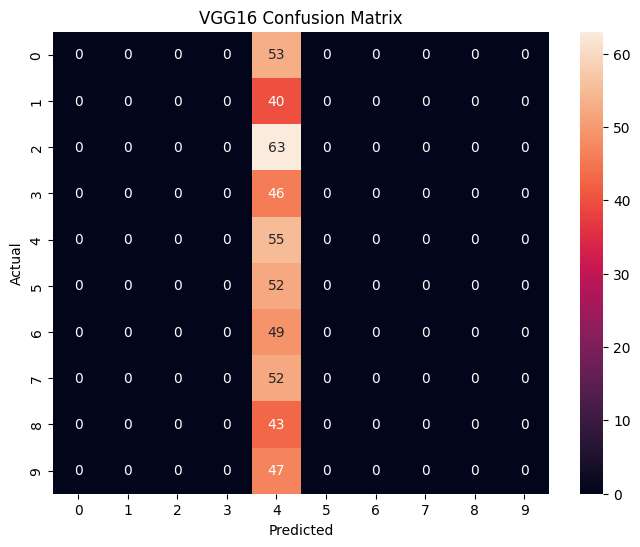

In [85]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_small,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

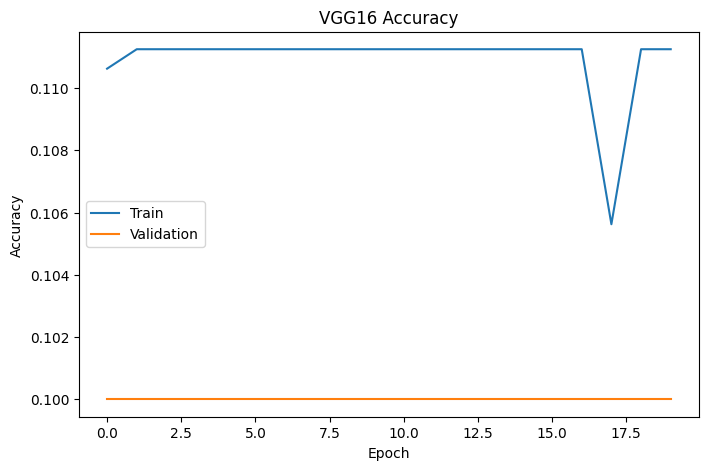

In [86]:
# ACCURACY GRAPH

plt.figure(figsize=(8,5))

plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])

plt.title('VGG16 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Train',
    'Validation'
])

plt.show()

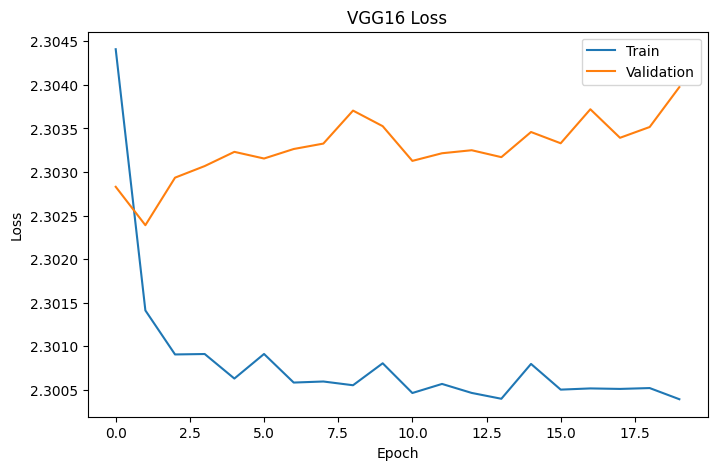

In [87]:
# LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])

plt.title('VGG16 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Train',
    'Validation'
])

plt.show()

In [88]:
print(len(history_vgg.history['accuracy']))
print(history_vgg.history['accuracy'][-1])
print(history_vgg.history['val_accuracy'][-1])

20
0.11124999821186066
0.10000000149011612


In [94]:
# RESNET50

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

resnet = ResNet50(
    weights=None,
    include_top=False,
    input_shape=(64,64,3)
)

resnet_model = Sequential([
    resnet,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_resnet = resnet_model.fit(
    X_train_resized,
    y_train_small,
    validation_split=0.2,
    epochs=2,
    batch_size=16,
    verbose=1
)

Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.4450 - loss: 1.7456 - val_accuracy: 0.0925 - val_loss: 2.6799
Epoch 2/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.6888 - loss: 0.9265 - val_accuracy: 0.1500 - val_loss: 4.3390


In [95]:
# EVALUATION

loss, accuracy = resnet_model.evaluate(
    X_test_resized,
    y_test_small,
    verbose=0
)

print("ResNet50 Accuracy:", accuracy)

ResNet50 Accuracy: 0.17000000178813934


In [96]:
# PRECISION, RECALL, F1

from sklearn.metrics import precision_score, recall_score, f1_score

y_pred_prob = resnet_model.predict(X_test_resized)
y_pred = np.argmax(y_pred_prob, axis=1)

precision = precision_score(y_test_small, y_pred, average='weighted')
recall = recall_score(y_test_small, y_pred, average='weighted')
f1 = f1_score(y_test_small, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 337ms/step
Precision: 0.16656817170111288
Recall: 0.17
F1 Score: 0.0999224141867379


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


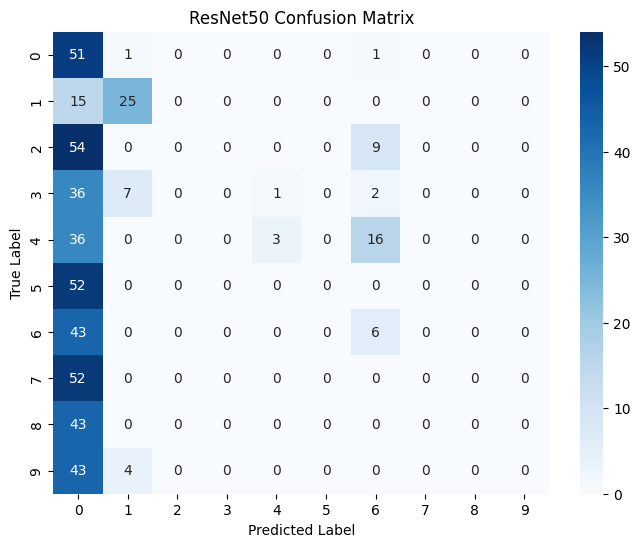

In [97]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_small,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

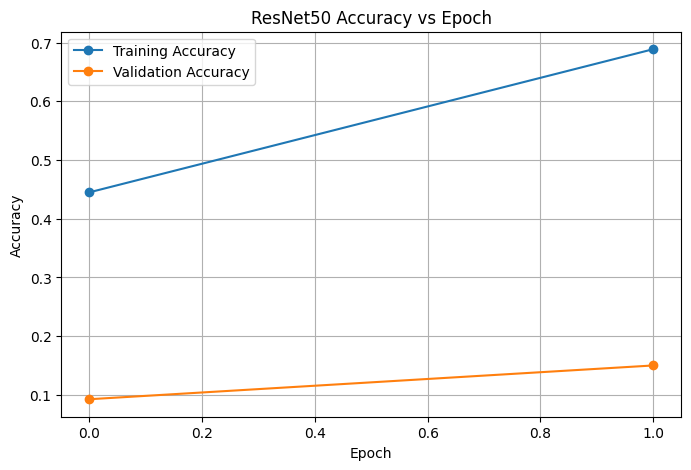

In [98]:
# ACCURACY GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    history_resnet.history['accuracy'],
    marker='o'
)

plt.plot(
    history_resnet.history['val_accuracy'],
    marker='o'
)

plt.title('ResNet50 Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.grid(True)

plt.show()

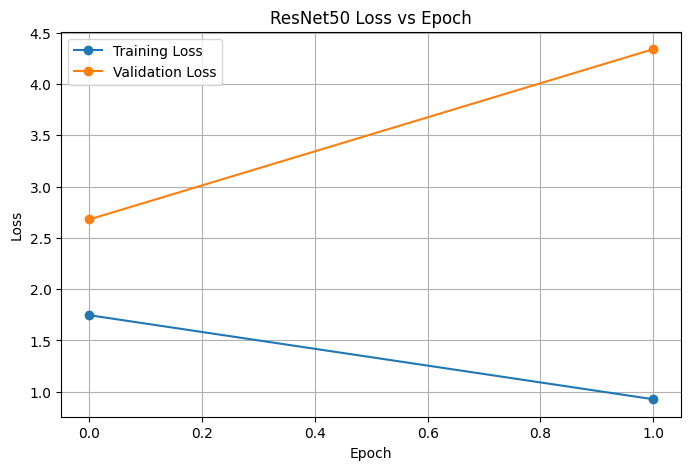

In [100]:
# LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    history_resnet.history['loss'],
    marker='o'
)

plt.plot(
    history_resnet.history['val_loss'],
    marker='o'
)

plt.title('ResNet50 Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.grid(True)

plt.show()

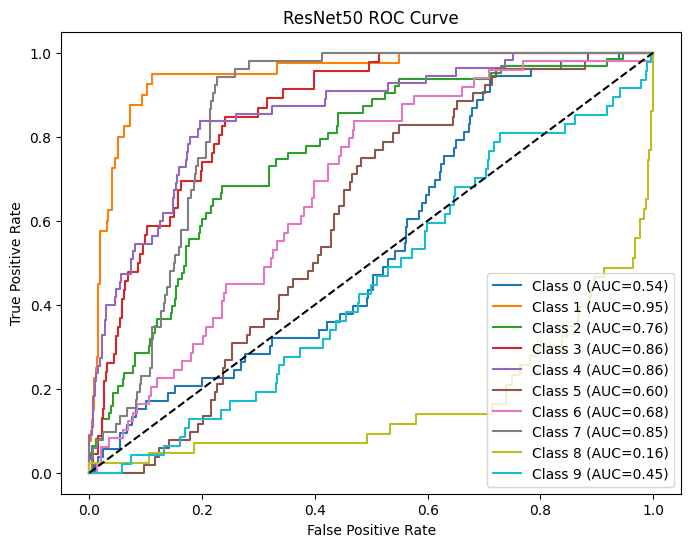

In [101]:
# ROC-AUC GRAPH

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(
    y_test_small,
    classes=range(10)
)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(10):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

plt.figure(figsize=(8,6))

for i in range(10):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i} (AUC={roc_auc[i]:.2f})'
    )

plt.plot(
    [0,1],
    [0,1],
    'k--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ResNet50 ROC Curve')

plt.legend(
    loc='lower right'
)

plt.show()


In [102]:
# DENSENET121

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

densenet = DenseNet121(
    weights=None,
    include_top=False,
    input_shape=(64,64,3)
)

densenet_model = Sequential([
    densenet,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

densenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

densenet_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 2, 2, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,103,754 (27.10 MB)

 Trainable params: 7,020,106 (26.78 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [103]:
# TRAIN

history_dense = densenet_model.fit(
    X_train_resized,
    y_train_small,
    validation_split=0.2,
    epochs=2,
    batch_size=16,
    verbose=1
)

Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 136s 646ms/step - accuracy: 0.6000 - loss: 1.1114 - val_accuracy: 0.0975 - val_loss: 2.6965
Epoch 2/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 601ms/step - accuracy: 0.7331 - loss: 0.7148 - val_accuracy: 0.1225 - val_loss: 3.2433


In [105]:
# ACCURACY

loss, accuracy = densenet_model.evaluate(
    X_test_resized,
    y_test_small,
    verbose=0
)

print("DenseNet121 Accuracy:", accuracy)

DenseNet121 Accuracy: 0.12600000202655792


In [106]:
# PREDICTIONS

import numpy as np

y_pred_prob = densenet_model.predict(
    X_test_resized
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 473ms/step


In [107]:
# PRECISION, RECALL, F1

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    y_test_small,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test_small,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test_small,
    y_pred,
    average='weighted'
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.015875999999999998
Recall: 0.126
F1 Score: 0.02819893428063943


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


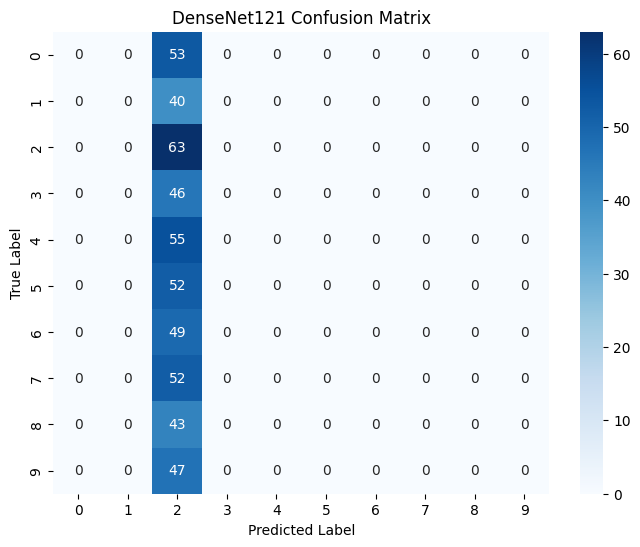

In [108]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_small,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("DenseNet121 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

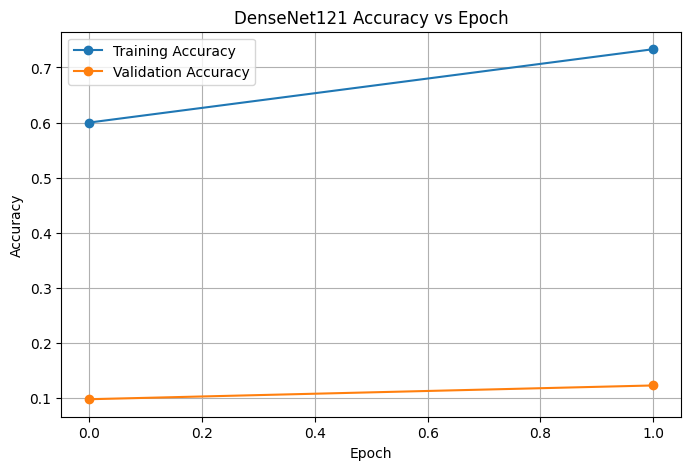

In [109]:
# ACCURACY GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    history_dense.history['accuracy'],
    marker='o'
)

plt.plot(
    history_dense.history['val_accuracy'],
    marker='o'
)

plt.title('DenseNet121 Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.grid(True)

plt.show()

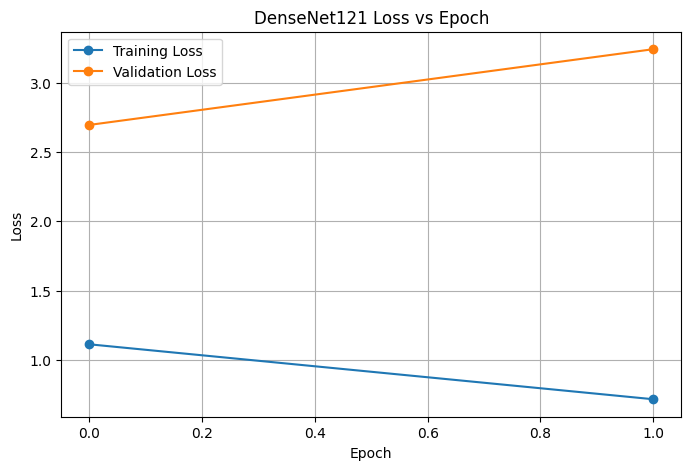

In [110]:
# LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(
    history_dense.history['loss'],
    marker='o'
)

plt.plot(
    history_dense.history['val_loss'],
    marker='o'
)

plt.title('DenseNet121 Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.grid(True)

plt.show()

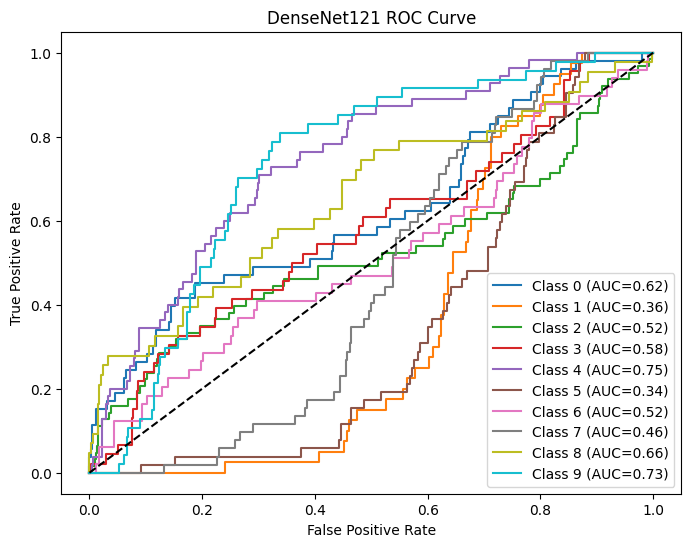

In [111]:
# ROC CURVE

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(
    y_test_small,
    classes=range(10)
)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(10):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

plt.figure(figsize=(8,6))

for i in range(10):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i} (AUC={roc_auc[i]:.2f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('DenseNet121 ROC Curve')

plt.legend(loc='lower right')

plt.show()